<a href="https://colab.research.google.com/github/arafatro/IntroToDS/blob/main/Practice%20Materials/Week%205/DS_Practice_Visualization_Pack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/arafatro/IntroToDS/blob/main/Practice%20Materials/Week%207/DS_Practice_Visualization_Pack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Data Science
## Practice Session — Visualization Pack: 4-Plot EDA + Storytelling
**Eötvös Loránd University (ELTE) · Faculty of Informatics**

---
**Instructor:** Arafat Md Easin  
**Goal:** By the end of this session you will be able to:
- Understand the **4-Plot EDA framework** and when to apply each plot type
- Build a **univariate distribution** plot (histogram + KDE + boxplot)
- Build a **bivariate relationship** plot (scatter + regression)
- Build a **grouped comparison** plot (boxplot/violin by category)
- Build a **trend / index** plot (line chart, rolling average)
- Combine all four into a **storytelling dashboard** that communicates a data narrative

> **Tip:** Run each cell with `Shift + Enter` and read the comments carefully before moving on.  
> **Key principle:** Every plot should answer a specific question. If you cannot state the question, you do not need the plot.

---
## Part 0 — Setup & Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Reproducible randomness ───────────────────────────────────────────
RNG = np.random.default_rng(seed=42)

# ── Plot style ────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"]    = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("Setup complete.")

Setup complete.


In [2]:
# ── Load datasets ─────────────────────────────────────────────────────
# We use two built-in seaborn datasets:
#   mpg   — fuel efficiency of cars (1970–1982), good for trend + grouped analysis
#   tips  — restaurant tipping data, good for grouped comparison

mpg  = sns.load_dataset("mpg").dropna()
tips = sns.load_dataset("tips")

# Quick look
print("mpg shape:", mpg.shape)
print("tips shape:", tips.shape)
print()
print(mpg.dtypes)
print()
mpg.head(3)

mpg shape: (392, 9)
tips shape: (244, 7)

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object



,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite


---
## Part 1 — The 4-Plot EDA Framework

Exploratory Data Analysis (EDA) is the process of understanding data visually before modelling.  
A useful starting discipline is the **4-Plot EDA Pack** — four complementary views that together give a complete picture:

| Plot | Question it answers | Typical tool |
|---|---|---|
| **Univariate distribution** | What does this variable look like on its own? | Histogram, KDE, Boxplot |
| **Bivariate relationship** | How do two numerical variables relate? | Scatter + regression line |
| **Grouped comparison** | Does a numerical variable differ across groups? | Boxplot / Violin by category |
| **Trend / Index** | How does a variable change over time or a sequence? | Line chart, rolling average |

> **Why four?** Each plot type catches a different class of pattern.  
> A variable can look normal univariately, have a curved bivariate relationship, differ dramatically across groups, AND follow a time trend — these are independent findings.

The workflow is:
1. Look at each variable alone (univariate).
2. Look at pairs (bivariate).
3. Condition on a category (grouped).
4. Look at the sequence or time axis (trend).
5. Weave findings into a **story**.

In [3]:
# ── 1.1  Quick variable overview ──────────────────────────────────────
# Before plotting, always know what you have.

print("=== mpg dataset ===")
print(mpg[["mpg","cylinders","horsepower","weight","model_year","origin"]].describe().round(2))
print()
print("Unique origins:", mpg["origin"].unique())
print("Model years:", sorted(mpg["model_year"].unique()))

=== mpg dataset ===
          mpg  cylinders  horsepower   weight  model_year
count  392.00     392.00      392.00   392.00      392.00
mean    23.45       5.47      104.47  2977.58       75.98
std      7.81       1.71       38.49   849.40        3.68
min      9.00       3.00       46.00  1613.00       70.00
25%     17.00       4.00       75.00  2225.25       73.00
50%     22.75       4.00       93.50  2803.50       76.00
75%     29.00       8.00      126.00  3614.75       79.00
max     46.60       8.00      230.00  5140.00       82.00

Unique origins: ['usa' 'japan' 'europe']
Model years: [np.int64(70), np.int64(71), np.int64(72), np.int64(73), np.int64(74), np.int64(75), np.int64(76), np.int64(77), np.int64(78), np.int64(79), np.int64(80), np.int64(81), np.int64(82)]


---
## Part 2 — Plot 1: Univariate Distribution

A univariate distribution plot answers: **"What does this variable look like?"**

Three tools together give the full picture:
- **Histogram** — shows the shape, spread, and any gaps
- **KDE (Kernel Density Estimate)** — a smooth version of the histogram
- **Boxplot** — shows median, quartiles, and outliers compactly

> **Rule:** Always look at a variable's distribution before using it in any model or comparison.

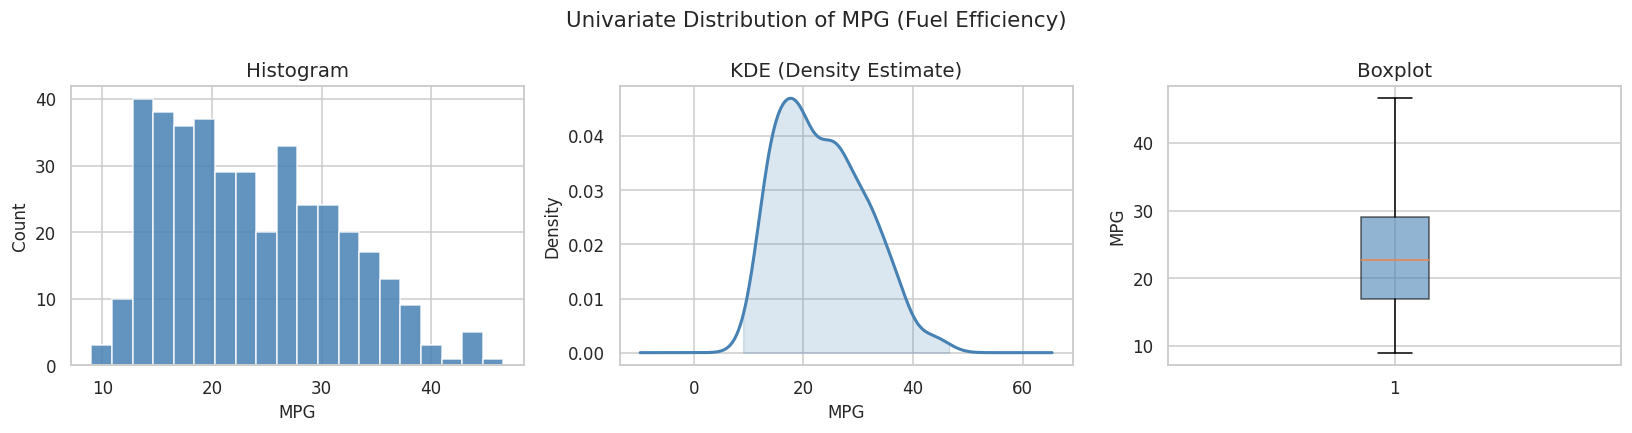

Mean: 23.45   Median: 22.75   Std: 7.81
Skewness: 0.457  (positive = right tail)


In [4]:
# ── 2.1  Univariate distribution — mpg (fuel efficiency) ──────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Univariate Distribution of MPG (Fuel Efficiency)", fontsize=14)

# Histogram
axes[0].hist(mpg["mpg"], bins=20, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("MPG")
axes[0].set_ylabel("Count")
axes[0].set_title("Histogram")

# KDE
mpg["mpg"].plot.kde(ax=axes[1], color="steelblue", linewidth=2)
axes[1].set_xlabel("MPG")
axes[1].set_title("KDE (Density Estimate)")
axes[1].fill_between(
    np.linspace(mpg["mpg"].min(), mpg["mpg"].max(), 200),
    stats.gaussian_kde(mpg["mpg"])(np.linspace(mpg["mpg"].min(), mpg["mpg"].max(), 200)),
    alpha=0.2, color="steelblue"
)

# Boxplot
axes[2].boxplot(mpg["mpg"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[2].set_ylabel("MPG")
axes[2].set_title("Boxplot")

plt.tight_layout()
plt.show()

print(f"Mean: {mpg['mpg'].mean():.2f}   Median: {mpg['mpg'].median():.2f}   Std: {mpg['mpg'].std():.2f}")
print(f"Skewness: {mpg['mpg'].skew():.3f}  (positive = right tail)")

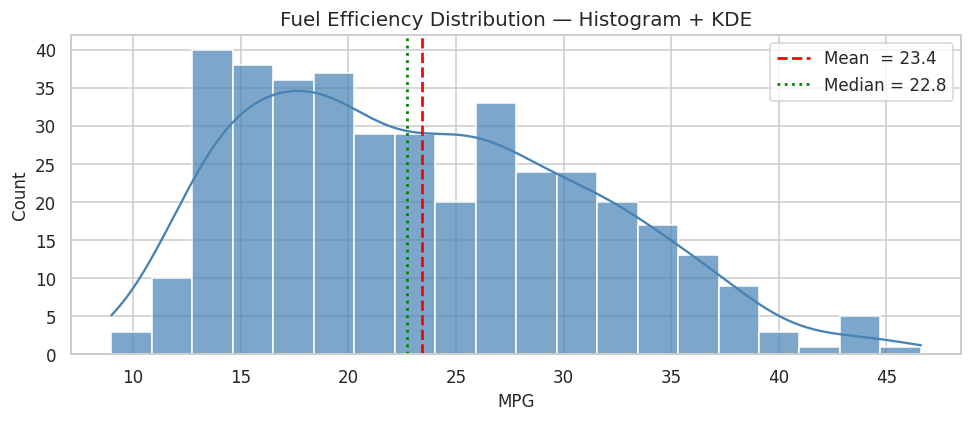

Observation: The distribution is right-skewed — most cars cluster 15–25 MPG,
with a long tail of efficient vehicles above 35 MPG.


In [5]:
# ── 2.2  Combined: histogram + KDE + rug ──────────────────────────────
# sns.histplot with kde=True overlays both in one panel

fig, ax = plt.subplots(figsize=(9, 4))

sns.histplot(mpg["mpg"], bins=20, kde=True, color="steelblue",
             edgecolor="white", alpha=0.7, ax=ax)
ax.axvline(mpg["mpg"].mean(),   color="red",    linestyle="--", linewidth=1.8,
           label=f"Mean  = {mpg['mpg'].mean():.1f}")
ax.axvline(mpg["mpg"].median(), color="green",  linestyle=":",  linewidth=1.8,
           label=f"Median = {mpg['mpg'].median():.1f}")

ax.set_xlabel("MPG")
ax.set_ylabel("Count")
ax.set_title("Fuel Efficiency Distribution — Histogram + KDE")
ax.legend()
plt.tight_layout()
plt.show()

print("Observation: The distribution is right-skewed — most cars cluster 15–25 MPG,")
print("with a long tail of efficient vehicles above 35 MPG.")

### Exercise 1
Using the `tips` dataset, analyse the distribution of `total_bill`.

1. Plot a **histogram** (20 bins), a **KDE**, and a **boxplot** side by side (1 row, 3 columns).
2. Add vertical lines for mean and median on the histogram panel.
3. Is the distribution symmetric, left-skewed, or right-skewed? How can you tell from both the plot and the skewness value?
4. Print the mean, median, standard deviation, and skewness.

```python
# Your code here
```

In [ ]:
# Your answer here


---
## Part 3 — Plot 2: Bivariate Relationship

A bivariate plot answers: **"How do two numerical variables relate to each other?"**

Key elements to report:
- **Direction**: positive, negative, or none
- **Form**: linear, curved, or no pattern
- **Strength**: tight cloud = strong, loose = weak
- **Outliers**: unusual points that break the pattern

Add a regression line to make the trend explicit, and a LOWESS smoother to detect nonlinearity.

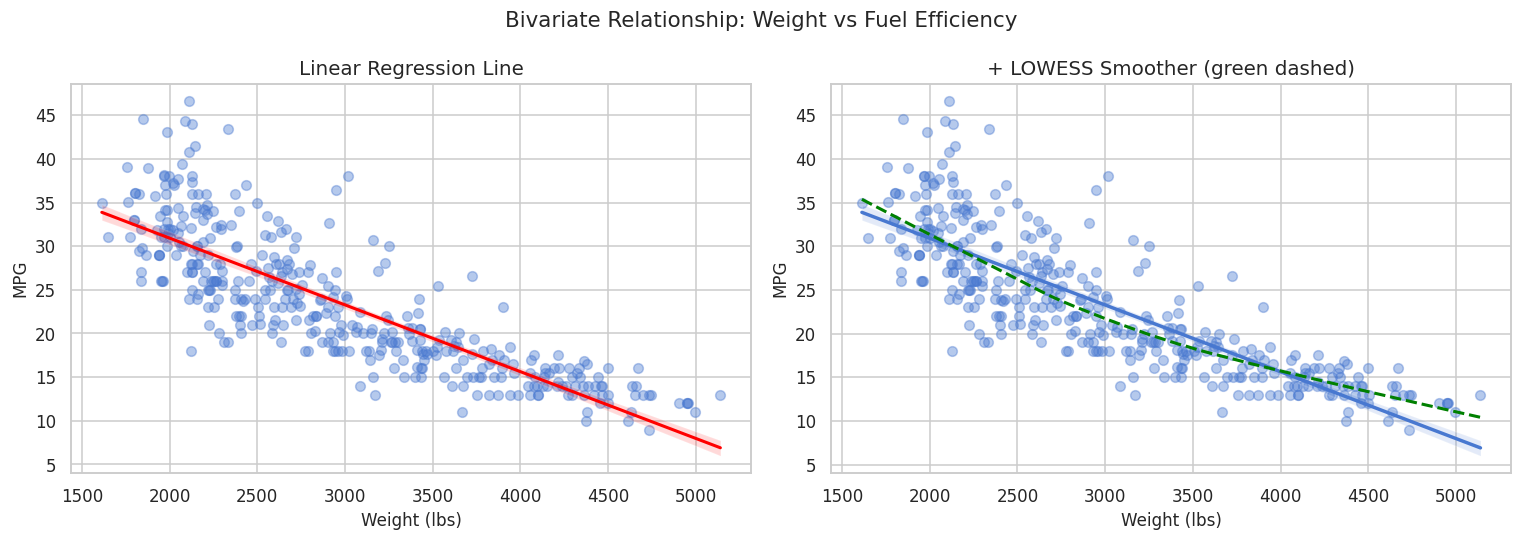

Pearson r = -0.832,  p-value = 6.02e-102
Strong negative relationship: heavier cars are significantly less fuel-efficient.


In [6]:
# ── 3.1  Scatter plot + regression line: weight vs mpg ─────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Bivariate Relationship: Weight vs Fuel Efficiency", fontsize=14)

# Left: plain scatter + regression
sns.regplot(data=mpg, x="weight", y="mpg",
            scatter_kws={"alpha": 0.4, "s": 40},
            line_kws={"color": "red", "linewidth": 2},
            ax=axes[0])
axes[0].set_title("Linear Regression Line")
axes[0].set_xlabel("Weight (lbs)")
axes[0].set_ylabel("MPG")

# Right: scatter + LOWESS smoother to detect nonlinearity
sns.regplot(data=mpg, x="weight", y="mpg",
            scatter_kws={"alpha": 0.4, "s": 40},
            ax=axes[1])
sns.regplot(data=mpg, x="weight", y="mpg",
            scatter=False, lowess=True,
            line_kws={"color": "green", "linewidth": 2, "linestyle": "--"},
            ax=axes[1])
axes[1].set_title("+ LOWESS Smoother (green dashed)")
axes[1].set_xlabel("Weight (lbs)")
axes[1].set_ylabel("MPG")

plt.tight_layout()
plt.show()

r, p = stats.pearsonr(mpg["weight"], mpg["mpg"])
print(f"Pearson r = {r:.3f},  p-value = {p:.2e}")
print("Strong negative relationship: heavier cars are significantly less fuel-efficient.")

### Exercise 2
Investigate the relationship between `horsepower` and `mpg` in the `mpg` dataset.

1. Create a scatter plot with a **linear regression line** and a **LOWESS smoother** side by side.
2. Compute **Pearson r** and its p-value.
3. Does the relationship appear linear or nonlinear? Use both the LOWESS curve and the correlation value to justify your answer.
4. Is there a direction? Is it stronger or weaker than the weight–mpg relationship?

```python
# Your code here
```

In [ ]:
# Your answer here


---
## Part 4 — Plot 3: Grouped Comparison

A grouped comparison answers: **"Does a numerical variable differ across categories?"**

Tools:
- **Boxplot by group** — shows median, spread, and outliers per group
- **Violin plot** — adds the full distribution shape
- **Strip / swarm plot** — shows individual data points
- **Bar chart of group means + error bars** — compact summary

> **When to use which?**  
> Small samples (< 30 per group) → strip/swarm.  
> Medium samples → boxplot.  
> Large samples → violin.

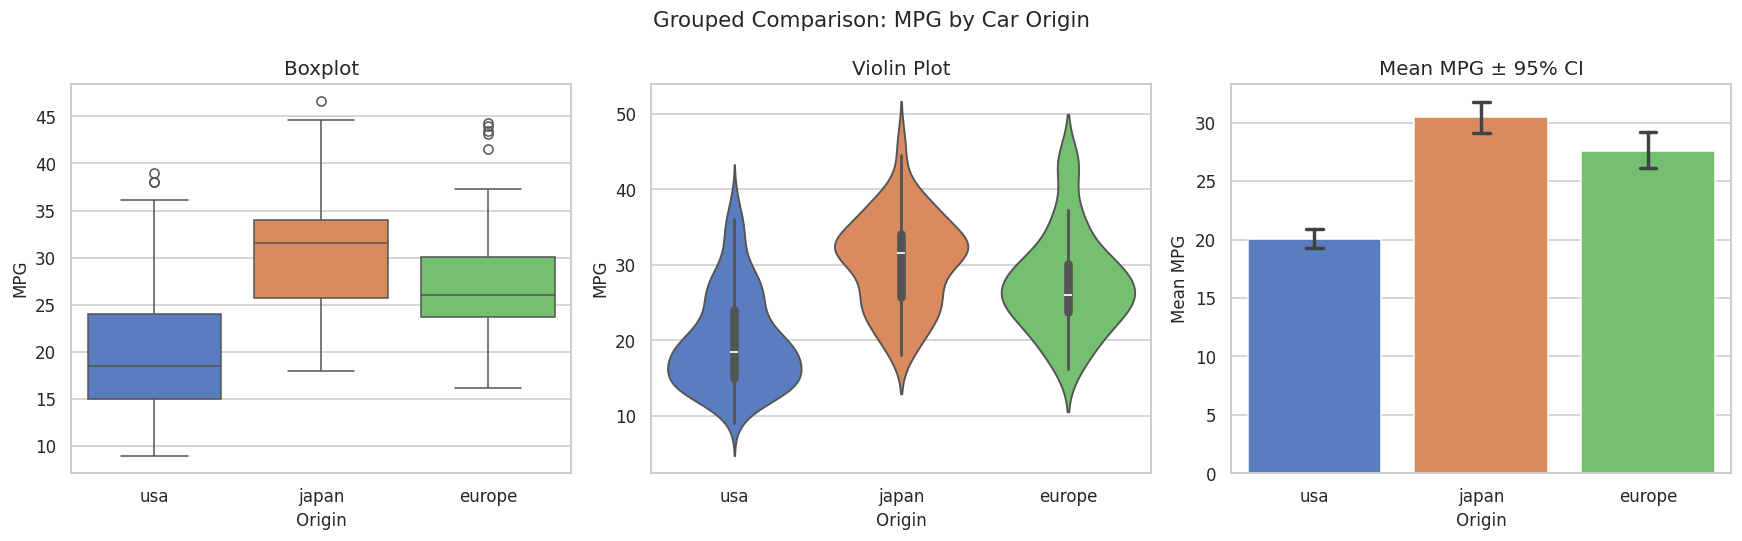

         mean  median   std  count
origin                            
europe  27.60    26.0  6.58     68
japan   30.45    31.6  6.09     79
usa     20.03    18.5  6.44    245


In [7]:
# ── 4.1  Boxplot by origin: does fuel efficiency vary by region? ────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Grouped Comparison: MPG by Car Origin", fontsize=14)

# Boxplot
sns.boxplot(data=mpg, x="origin", y="mpg", palette="muted", ax=axes[0])
axes[0].set_title("Boxplot")
axes[0].set_xlabel("Origin")
axes[0].set_ylabel("MPG")

# Violin
sns.violinplot(data=mpg, x="origin", y="mpg", palette="muted", inner="box", ax=axes[1])
axes[1].set_title("Violin Plot")
axes[1].set_xlabel("Origin")
axes[1].set_ylabel("MPG")

# Bar chart of means + 95% CI
sns.barplot(data=mpg, x="origin", y="mpg", palette="muted",
            capsize=0.1, ax=axes[2])
axes[2].set_title("Mean MPG ± 95% CI")
axes[2].set_xlabel("Origin")
axes[2].set_ylabel("Mean MPG")

plt.tight_layout()
plt.show()

# Print group statistics
print(mpg.groupby("origin")["mpg"].agg(["mean","median","std","count"]).round(2))

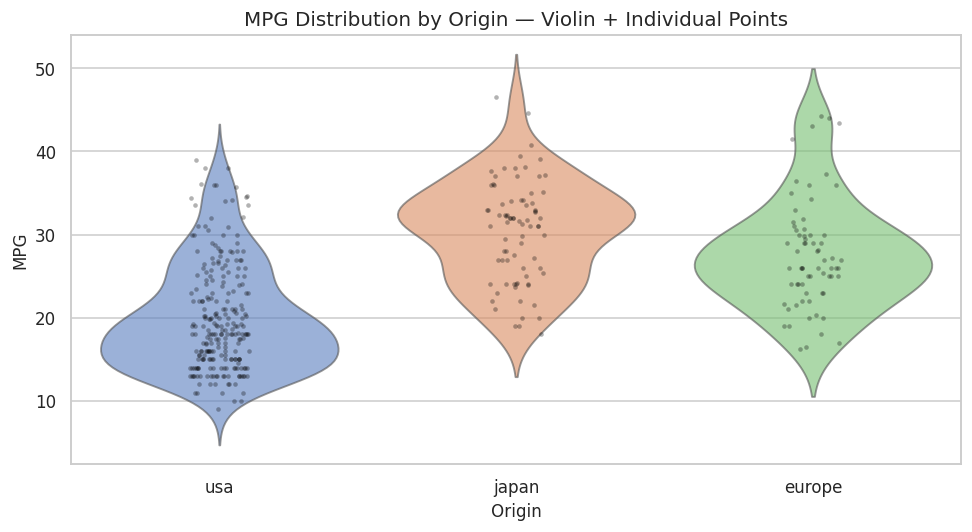

Observation: Japanese cars are substantially more fuel-efficient on average.
US cars show the most spread and the lowest median efficiency.


In [8]:
# ── 4.2  Violin + strip overlay — see the data behind the summary ──────

fig, ax = plt.subplots(figsize=(9, 5))

sns.violinplot(data=mpg, x="origin", y="mpg",
               palette="muted", inner=None, alpha=0.6, ax=ax)
sns.stripplot(data=mpg, x="origin", y="mpg",
              color="black", alpha=0.3, size=3, jitter=True, ax=ax)

ax.set_title("MPG Distribution by Origin — Violin + Individual Points")
ax.set_xlabel("Origin")
ax.set_ylabel("MPG")
plt.tight_layout()
plt.show()

print("Observation: Japanese cars are substantially more fuel-efficient on average.")
print("US cars show the most spread and the lowest median efficiency.")

### Exercise 3
Using the `tips` dataset, compare `total_bill` across the `day` of the week.

1. Create a **boxplot** of `total_bill` by `day`.
2. Overlay a **strip plot** to show individual points.
3. Compute and print the **mean** and **median** `total_bill` for each day.
4. On which day do customers spend the most on average? Is there a day with unusually high variability?
5. Write one sentence interpreting the grouped pattern.

```python
# Your code here
```

In [ ]:
# Your answer here


---
## Part 5 — Plot 4: Trend / Index Plot

A trend plot answers: **"How does a variable change over time or a sequence?"**

Tools:
- **Line chart** — the standard time-series view
- **Rolling average** — smooths short-term noise to reveal the underlying trend
- **Area chart** — emphasises volume or cumulative change

> **Index plot tip:** When comparing variables with different units or scales, **index** them to a common baseline (e.g., value at year 0 = 100). This lets you compare percentage change rather than absolute values.

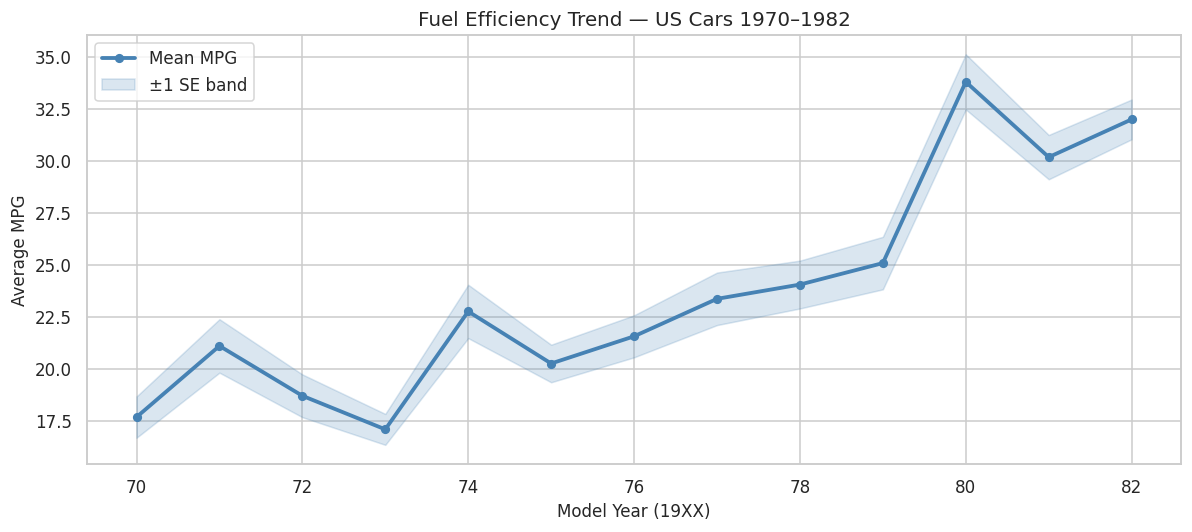

Observation: Average MPG improved dramatically from ~17 (1970) to ~32 (1982),
likely driven by the 1973 and 1979 oil crises forcing manufacturers to build lighter cars.


In [9]:
# ── 5.1  Average MPG by model year — tracking the efficiency trend ──────

yearly = (
    mpg.groupby("model_year")["mpg"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
yearly.columns = ["year", "mean_mpg", "std_mpg", "n"]
yearly["se"] = yearly["std_mpg"] / np.sqrt(yearly["n"])   # standard error

fig, ax = plt.subplots(figsize=(11, 5))

# Trend line
ax.plot(yearly["year"], yearly["mean_mpg"],
        color="steelblue", linewidth=2.5, marker="o", markersize=5,
        label="Mean MPG")

# Confidence band (±1 SE)
ax.fill_between(yearly["year"],
                yearly["mean_mpg"] - yearly["se"],
                yearly["mean_mpg"] + yearly["se"],
                alpha=0.2, color="steelblue", label="±1 SE band")

ax.set_xlabel("Model Year (19XX)")
ax.set_ylabel("Average MPG")
ax.set_title("Fuel Efficiency Trend — US Cars 1970–1982")
ax.legend()
plt.tight_layout()
plt.show()

print("Observation: Average MPG improved dramatically from ~17 (1970) to ~32 (1982),")
print("likely driven by the 1973 and 1979 oil crises forcing manufacturers to build lighter cars.")

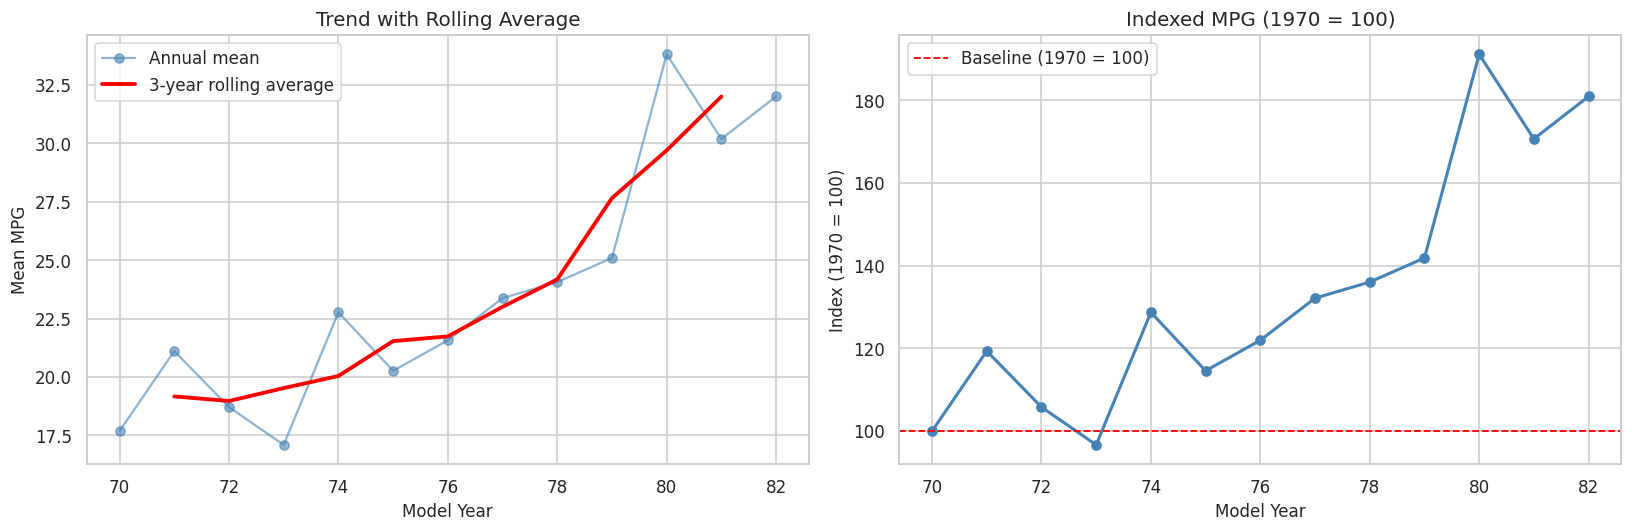

By 1982, average MPG had increased to 181% of the 1970 baseline.


In [10]:
# ── 5.2  Rolling average + index normalisation ────────────────────────

# Rolling average (window=3 years) smooths year-to-year noise
yearly["rolling_3yr"] = yearly["mean_mpg"].rolling(window=3, center=True).mean()

# Index: set 1970 = 100 for a percentage-change view
base = yearly.loc[yearly["year"] == 70, "mean_mpg"].values[0]
yearly["index_mpg"] = (yearly["mean_mpg"] / base) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: raw trend + rolling average
axes[0].plot(yearly["year"], yearly["mean_mpg"],
             "o-", color="steelblue", linewidth=1.5, alpha=0.6, label="Annual mean")
axes[0].plot(yearly["year"], yearly["rolling_3yr"],
             color="red", linewidth=2.5, label="3-year rolling average")
axes[0].set_title("Trend with Rolling Average")
axes[0].set_xlabel("Model Year")
axes[0].set_ylabel("Mean MPG")
axes[0].legend()

# Right: indexed to 1970 = 100
axes[1].plot(yearly["year"], yearly["index_mpg"],
             "o-", color="steelblue", linewidth=2)
axes[1].axhline(100, color="red", linestyle="--", linewidth=1.2,
                label="Baseline (1970 = 100)")
axes[1].set_title("Indexed MPG (1970 = 100)")
axes[1].set_xlabel("Model Year")
axes[1].set_ylabel("Index (1970 = 100)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"By 1982, average MPG had increased to {yearly.iloc[-1]['index_mpg']:.0f}% of the 1970 baseline.")

### Exercise 4
Investigate the trend in **average horsepower** over model years in the `mpg` dataset.

1. Compute the mean `horsepower` per `model_year`.
2. Plot the annual trend as a **line chart** with markers.
3. Overlay a **3-year rolling average** to smooth the trend.
4. Create an **index plot** (1970 = 100) to show the percentage change.
5. How did horsepower change over the 1970s? Is the trend consistent with the MPG trend? Why or why not?

```python
# Your code here
```

In [ ]:
# Your answer here


---
## Part 6 — The 4-Plot EDA Dashboard: Storytelling

A single plot answers a single question.  
A **dashboard** combines multiple plots to tell a coherent **data story**.

**Storytelling checklist:**
1. **Headline**: What is the one-sentence summary?
2. **Evidence**: Which plots support it?
3. **Nuance**: What complicates or qualifies the story?
4. **Action**: What decision or question does this raise?

> **Design rules for dashboards:**
> - Each panel should answer exactly one question.
> - Use a shared axis where possible to allow direct comparison.
> - Annotate the most important finding directly on the plot.
> - Title the figure as a headline, not a label.

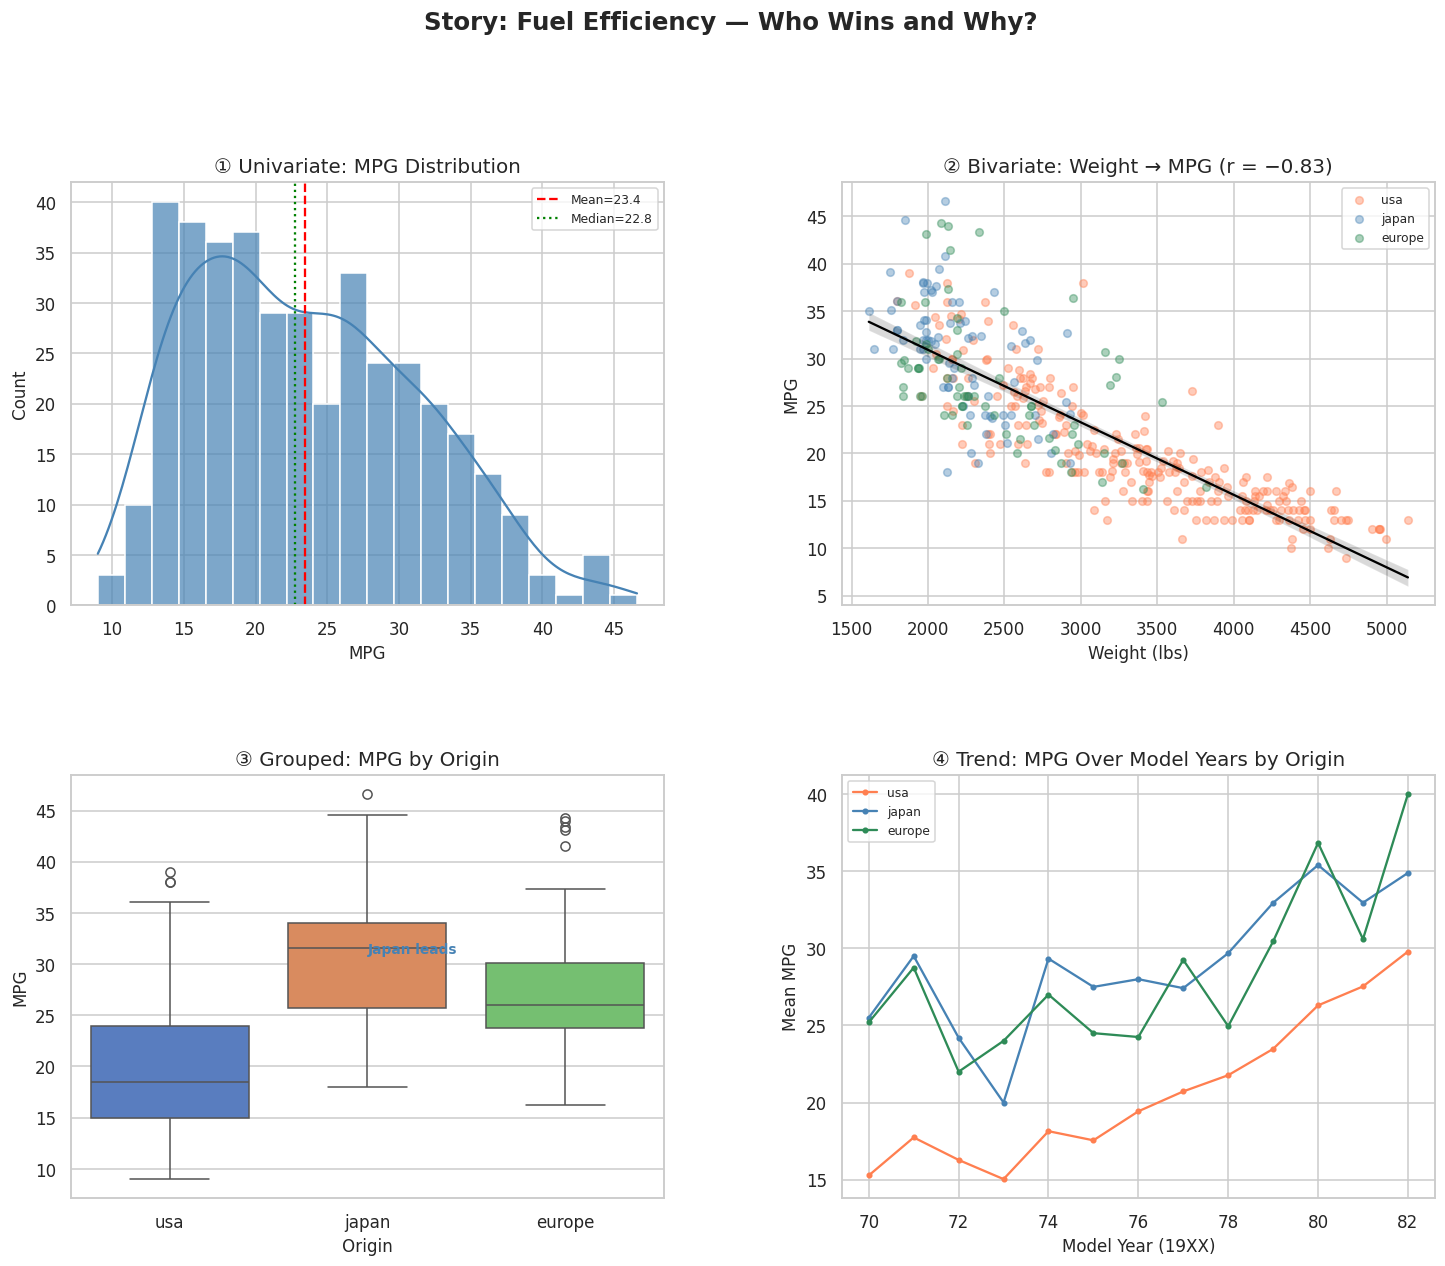

Dashboard saved as eda_dashboard.png


In [11]:
# ── 6.1  The 4-Plot EDA Dashboard — Fuel Efficiency Story ──────────────
# Story: "Japanese cars became the efficiency winners of the 1970s oil crisis era"

fig = plt.figure(figsize=(16, 12))
fig.suptitle("Story: Fuel Efficiency — Who Wins and Why?", fontsize=16, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.3)

# ── Panel 1: Univariate — MPG distribution ────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(mpg["mpg"], bins=20, kde=True, color="steelblue",
             edgecolor="white", alpha=0.7, ax=ax1)
ax1.axvline(mpg["mpg"].mean(),   color="red", linestyle="--", linewidth=1.5,
            label=f"Mean={mpg['mpg'].mean():.1f}")
ax1.axvline(mpg["mpg"].median(), color="green", linestyle=":",  linewidth=1.5,
            label=f"Median={mpg['mpg'].median():.1f}")
ax1.set_title("① Univariate: MPG Distribution")
ax1.set_xlabel("MPG")
ax1.legend(fontsize=8)

# ── Panel 2: Bivariate — weight vs mpg ───────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for origin, color in zip(["usa", "japan", "europe"], ["coral", "steelblue", "seagreen"]):
    subset = mpg[mpg["origin"] == origin]
    ax2.scatter(subset["weight"], subset["mpg"],
                alpha=0.4, s=25, label=origin, color=color)
# Overall regression
sns.regplot(data=mpg, x="weight", y="mpg", scatter=False,
            line_kws={"color": "black", "linewidth": 1.5}, ax=ax2)
ax2.set_title("② Bivariate: Weight → MPG (r = −0.83)")
ax2.set_xlabel("Weight (lbs)")
ax2.set_ylabel("MPG")
ax2.legend(fontsize=8)

# ── Panel 3: Grouped — mpg by origin ─────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
sns.boxplot(data=mpg, x="origin", y="mpg", palette="muted", ax=ax3)
ax3.set_title("③ Grouped: MPG by Origin")
ax3.set_xlabel("Origin")
ax3.set_ylabel("MPG")
# Annotate Japanese advantage
ax3.annotate("Japan leads", xy=(1, 31), fontsize=9,
             color="steelblue", fontweight="bold")

# ── Panel 4: Trend — mpg over time ───────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
for origin, color in zip(["usa", "japan", "europe"], ["coral", "steelblue", "seagreen"]):
    trend = mpg[mpg["origin"] == origin].groupby("model_year")["mpg"].mean()
    ax4.plot(trend.index, trend.values,
             marker="o", markersize=3, linewidth=1.5, label=origin, color=color)
ax4.set_title("④ Trend: MPG Over Model Years by Origin")
ax4.set_xlabel("Model Year (19XX)")
ax4.set_ylabel("Mean MPG")
ax4.legend(fontsize=8)

plt.tight_layout()
plt.savefig("eda_dashboard.png", dpi=110, bbox_inches="tight")
plt.show()
print("Dashboard saved as eda_dashboard.png")

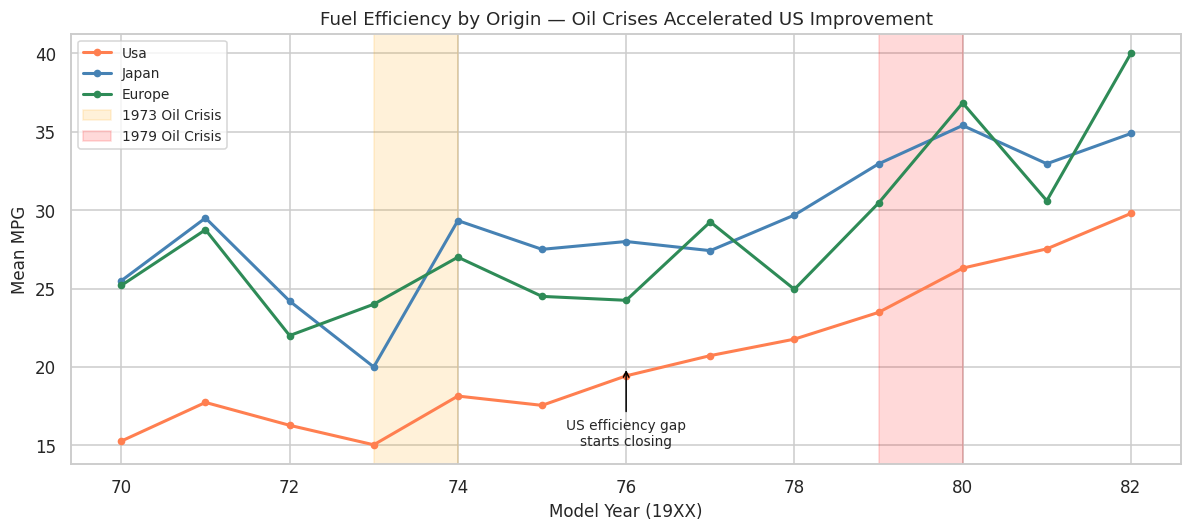

Story headline: Oil crises forced US manufacturers to close the fuel efficiency gap,
but Japanese cars maintained their lead throughout the decade.


In [13]:
# ── 6.2  Adding storytelling annotations ─────────────────────────────
# Good data stories annotate the KEY finding directly on the plot.

fig, ax = plt.subplots(figsize=(11, 5))

for origin, color in zip(["usa", "japan", "europe"], ["coral", "steelblue", "seagreen"]):
    trend = mpg[mpg["origin"] == origin].groupby("model_year")["mpg"].mean()
    ax.plot(trend.index, trend.values,
            marker="o", markersize=4, linewidth=2, label=origin.title(), color=color)

# Annotate the oil crisis
ax.axvspan(73, 74, alpha=0.15, color="orange", label="1973 Oil Crisis")
ax.axvspan(79, 80, alpha=0.15, color="red",    label="1979 Oil Crisis")

ax.annotate("US efficiency gap\nstarts closing", xy=(76, 20),
            xytext=(76, 15), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="black"),
            ha="center")

ax.set_title("Fuel Efficiency by Origin — Oil Crises Accelerated US Improvement", fontsize=12)
ax.set_xlabel("Model Year (19XX)")
ax.set_ylabel("Mean MPG")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Story headline: Oil crises forced US manufacturers to close the fuel efficiency gap,")
print("but Japanese cars maintained their lead throughout the decade.")

### Exercise 5 — Final Challenge

Using either the `mpg` or `tips` dataset, build your own **4-Plot EDA Dashboard** that tells a coherent data story.

1. **Choose a story** — write it as a one-sentence headline before you start coding.
2. **Panel 1 (Univariate):** Plot the distribution of your key numerical variable with histogram + KDE.
3. **Panel 2 (Bivariate):** Plot its relationship with a second numerical variable including a regression line.
4. **Panel 3 (Grouped):** Compare your key variable across a categorical variable using boxplot or violin.
5. **Panel 4 (Trend):** Show how your key variable changes over a sequence or grouping axis.
6. Combine all four panels in a single `2×2` figure with a headline title.
7. Add **at least one annotation** on any panel that highlights the most important finding.
8. Write 3–4 sentences below the plot summarising what the dashboard shows, referencing each panel.

```python
# Your code here
```

In [ ]:
# Your answer here


---
## Summary

| Plot Type | Question | Key Tools |
|---|---|---|
| **Univariate** | What does this variable look like? | `histplot`, `kde`, `boxplot` |
| **Bivariate** | How do two numerical variables relate? | `regplot`, LOWESS, Pearson r |
| **Grouped comparison** | Does it differ across categories? | `boxplot`, `violinplot`, `barplot` |
| **Trend / Index** | How does it change over time? | Line chart, rolling mean, index |
| **Dashboard** | What is the full story? | `GridSpec`, annotations, headline title |

---
**The data storytelling loop:**
1. Ask a question → 2. Choose the right plot → 3. Annotate the key finding → 4. Write the headline → 5. Identify the next question.